# 第0章 確率・確率密度の基礎補講 (Foundations of Probability)

本章は、PRMLを読み進める上で必要となる確率論・線形代数・解析学の数学的基礎知識を補うための特別な章です。
各章で新たな数学的道具が登場するたびに、この章を継続的にアップデートして体系化していきます。

## 0.1 確率の基本規則：加法定理と乗法定理

確率は以下の2つの基本定理から出発します。

- **加法定理 (Sum Rule)**:
  $$ p(X) = \sum_Y p(X, Y) \quad \text{または} \quad p(x) = \int p(x, y) dy $$
- **乗法定理 (Product Rule)**:
  $$ p(X, Y) = p(Y|X)p(X) $$

ここで、$p(X, Y)$ は同時確率、$p(Y|X)$ は条件付き確率、$p(X)$ は周辺確率です。

Plot saved to: result/fig0_1_dice_sum.png


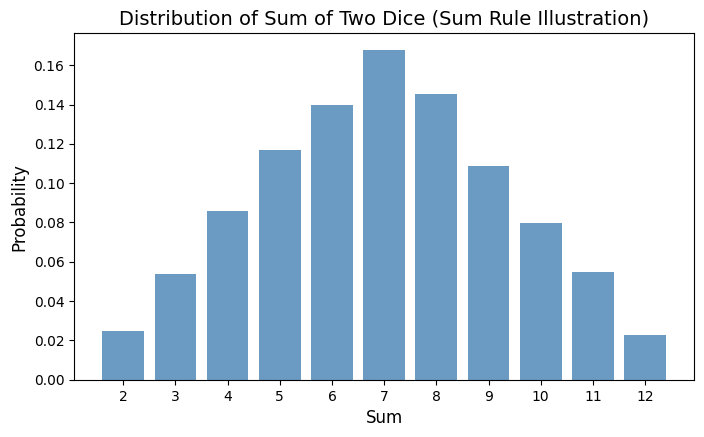

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# 2つのサイコロの目の和の分布を可視化（加法定理の直感）
rolls = np.random.randint(1, 7, size=(10000, 2))
sums = rolls.sum(axis=1)
fig = plt.figure(figsize=(8, 4.5))
plt.hist(sums, bins=np.arange(1.5, 13.5, 1), density=True, rwidth=0.8, color='steelblue', alpha=0.8)
plt.title('Distribution of Sum of Two Dice (Sum Rule Illustration)')
plt.xlabel('Sum')
plt.ylabel('Probability')
plt.xticks(range(2, 13))
save_plot(fig, 'result', 'fig0_1_dice_sum.png')
plt.show()

## 0.2 ベイズの定理 (Bayes' Theorem)

加法定理と乗法定理を組み合わせることで、機械学習の基礎となるベイズの定理が得られます。

$$ p(Y|X) = \frac{p(X|Y)p(Y)}{p(X)} = \frac{p(X|Y)p(Y)}{\sum_{Y'} p(X|Y')p(Y')} $$

- $p(Y)$: **事前確率 (Prior)** - データを観測する前の仮説 $Y$ の信念度
- $p(X|Y)$: **尤度 (Likelihood)** - 仮説 $Y$ が正しいとしたとき、観測データ $X$ が得られる確率
- $p(Y|X)$: **事後確率 (Posterior)** - 観測データ $X$ を得た後の仮説 $Y$ の信念度
- $p(X)$: **周辺尤度 / 規格化定数 (Evidence)** - すべての仮説にわたるデータの周辺確率

## 0.3 確率密度 (Probability Density) と変数変換

連続変数の場合、特定の一点 $x$ を取る確率は厳密には 0 となります。
微小区間 $(x, x + \delta x)$ に含まれる確率を $p(x)\delta x$ として定義し、$p(x)$ を確率密度と呼びます。

$$ p(x) \ge 0, \quad \int_{-\infty}^{\infty} p(x) dx = 1 $$

### 確率密度の変数変換 (Change of Variables)
非線形変換 $y = g(x)$ を行う場合、微小確率の保存則 $p_y(y)dy = p_x(x)dx$ より、ヤコビアン（Jacobian）の絶対値がかかります。

$$ p_y(y) = p_x(g^{-1}(y)) \left| \frac{dx}{dy} \right| $$

多変量の場合はヤコビ行列式 $|\det J|$ となります。この性質のため、通常の関数と異なり、**確率密度の最大値（最頻値）は変数の取り方（座標系）に依存して変化する**ことに注意が必要です。

## 0.4 期待値と分散・共分散

- **期待値 (Expectation)**:
  $$ \mathbb{E}[f] = \int p(x) f(x) dx $$
- **分散 (Variance)**:
  $$ \mathrm{var}[f] = \mathbb{E}[(f(x) - \mathbb{E}[f])^2] = \mathbb{E}[f(x)^2] - \mathbb{E}[f]^2 $$
- **共分散 (Covariance)**:
  $$ \mathrm{cov}[x, y] = \mathbb{E}_{x, y}[(x - \mathbb{E}[x])(y - \mathbb{E}[y])] $$
  ベクトルの場合、共分散行列は $\mathrm{cov}[\mathbf{x}] = \mathbb{E}[(\mathbf{x} - \mathbb{E}[\mathbf{x}])(\mathbf{x} - \mathbb{E}[\mathbf{x}])^T]$ と定義され、半正定値対称行列となります。

## 0.5 ガンマ関数とベータ関数 (第2章への補講)

第2章（連続確率分布、ベータ分布、ディリクレ分布、t分布など）において不可欠となる特殊関数です。

### ガンマ関数 (Gamma Function)
階乗 $n!$ を実数・複素数へ拡張した関数です。
$$ \Gamma(x) = \int_0^\infty t^{x-1} e^{-t} dt \quad (x > 0) $$
基本的な性質：
- $\Gamma(x + 1) = x \Gamma(x)$
- $n$ が自然数のとき $\Gamma(n) = (n - 1)!$
- $\Gamma(1/2) = \sqrt{\pi}$

### ベータ関数 (Beta Function)
$$ B(a, b) = \int_0^1 \mu^{a-1} (1 - \mu)^{b-1} d\mu $$
ガンマ関数との重要な関係式：
$$ B(a, b) = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a + b)} $$
これにより、ベータ分布 $\mathrm{Beta}(\mu|a, b) = \frac{1}{B(a, b)} \mu^{a-1}(1-\mu)^{b-1}$ の全積分が 1 になることが保証されます。

Plot saved to: result/fig0_2_gamma_function.png


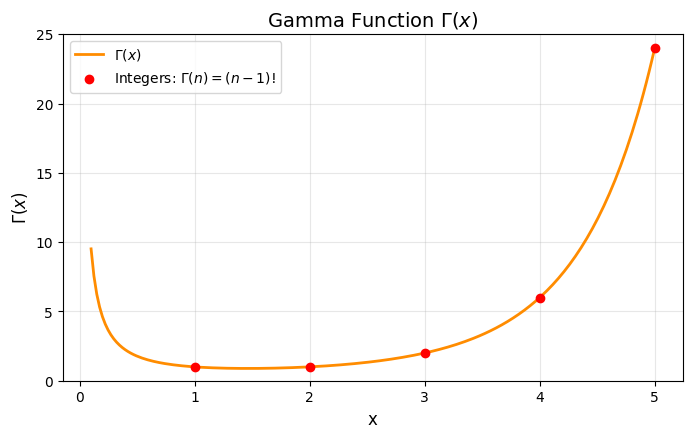

In [2]:
import scipy.special as sp

x = np.linspace(0.1, 5, 200)
gamma_vals = sp.gamma(x)

fig = plt.figure(figsize=(8, 4.5))
plt.plot(x, gamma_vals, label=r'$\Gamma(x)$', color='darkorange', lw=2)
# Mark integer values
integers = np.array([1, 2, 3, 4, 5])
plt.scatter(integers, sp.gamma(integers), color='red', zorder=5, label=r'Integers: $\Gamma(n)=(n-1)!$')
plt.ylim(0, 25)
plt.title('Gamma Function $\Gamma(x)$')
plt.xlabel('x')
plt.ylabel(r'$\Gamma(x)$')
plt.grid(True, alpha=0.3)
plt.legend()
save_plot(fig, 'result', 'fig0_2_gamma_function.png')
plt.show()

## 0.6 多変量正規分布の幾何学とマハラノビス距離

$D$ 次元多変量正規分布は以下で定義されます。
$$ \mathcal{N}(\mathbf{x}|\boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{D/2}|\boldsymbol{\Sigma}|^{1/2}} \exp\left( -\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right) $$

指数部の二次形式:
$$ \Delta^2 = (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) $$
は、中心 $\boldsymbol{\mu}$ からの**マハラノビス距離 (Mahalanobis distance)** の二乗と呼ばれます。
共分散行列 $\boldsymbol{\Sigma}$ の固有値分解 $\boldsymbol{\Sigma} = \sum_{i=1}^D \lambda_i \mathbf{u}_i \mathbf{u}_i^T$ を用いると、等確率面は主軸が固有ベクトル $\mathbf{u}_i$ 方向、軸長が $\sqrt{\lambda_i}$ に比例する楕円面（超楕円体）となります。

Plot saved to: result/fig0_3_gaussian_geometry.png


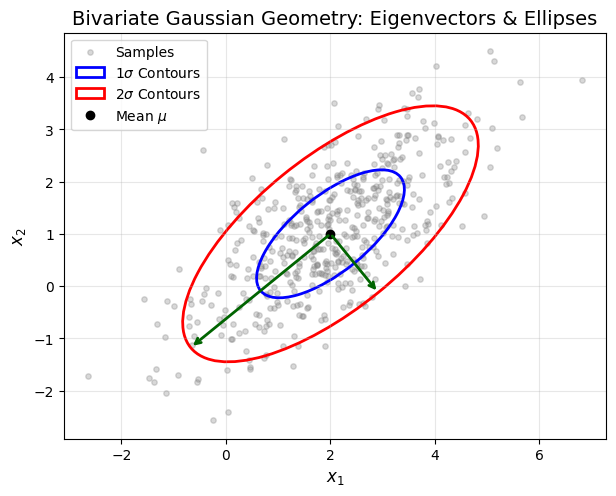

In [3]:
from common.distribution_utils import plot_gaussian_ellipse

mean = np.array([2.0, 1.0])
cov = np.array([[2.0, 1.2],
                [1.2, 1.5]])

# 固有値分解
vals, vecs = np.linalg.eigh(cov)

fig, ax = plt.subplots(figsize=(7, 6))
# 乱数サンプリング
np.random.seed(42)
samples = np.random.multivariate_normal(mean, cov, size=500)
ax.scatter(samples[:, 0], samples[:, 1], alpha=0.3, color='gray', s=15, label='Samples')

# 1-sigma, 2-sigma 楕円
plot_gaussian_ellipse(mean, cov, ax=ax, n_std=1.0, edgecolor='blue', lw=2, fill=False, label=r'$1\sigma$ Contours')
plot_gaussian_ellipse(mean, cov, ax=ax, n_std=2.0, edgecolor='red', lw=2, fill=False, label=r'$2\sigma$ Contours')

# 主軸（固有ベクトル）の描画
for val, vec in zip(vals, vecs.T):
    start = mean
    end = mean + 2.0 * np.sqrt(val) * vec
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', lw=2, color='darkgreen'))

ax.plot(mean[0], mean[1], 'ko', label=r'Mean $\mu$')
ax.set_title('Bivariate Gaussian Geometry: Eigenvectors & Ellipses')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
save_plot(fig, 'result', 'fig0_3_gaussian_geometry.png')
plt.show()

## 0.7 共役事前分布と十分統計量 (Conjugacy & Sufficient Statistics)

### 共役事前分布 (Conjugate Prior)
ベイズ推論において、事後分布 $p(\theta | \mathcal{D}) \propto p(\mathcal{D} | \theta) p(\theta)$ が事前分布 $p(\theta)$ と**同じ確率分布族の形を保つ**とき、その事前分布を**共役事前分布 (conjugate prior)** と呼びます。
- ベルヌーイ / 二項分布 $\to$ ベータ分布
- 多項分布 $\to$ ディリクレ分布
- ガウス分布（平均未知） $\to$ ガウス分布
- ガウス分布（分散未知） $\to$ ガンマ分布（多変量ならウィシャート分布）

### 十分統計量 (Sufficient Statistics)
パラメータ $\theta$ を推定する際、観測データ全体の情報のうち、パラメータの推論に必要な情報がすべて圧縮された関数の組を十分統計量と呼びます。
指数型分布族では、データ数 $N$ がどれほど増えても、十分統計量の次元は一定に保たれるという極めて都合の良い性質があります。

## 0.8 行列の恒等式と直交射影の幾何学 (ウッドベリーの公式と最小二乗射影)

PRMLの第2章（線形ガウスモデル）、第3章（線形回帰）、および第6章（カーネル法・ガウス過程）では、高度な行列恒等式と線形代数の幾何学的解釈が頻繁に登場します。

### 1. ウッドベリーの公式 (Woodbury Matrix Identity)
正則行列 $\mathbf{A} \in \mathbb{R}^{D 	imes D}$, $\mathbf{C} \in \mathbb{R}^{M 	imes M}$ と任意の行列 $\mathbf{U} \in \mathbb{R}^{D 	imes M}$, $\mathbf{V} \in \mathbb{R}^{M 	imes D}$ に対し、以下の恒等式が成り立ちます（PRML 付録 C.7）。

36385 (\mathbf{A} + \mathbf{U}\mathbf{C}\mathbf{V})^{-1} = \mathbf{A}^{-1} - \mathbf{A}^{-1}\mathbf{U} (\mathbf{C}^{-1} + \mathbf{V}\mathbf{A}^{-1}\mathbf{U})^{-1} \mathbf{V}\mathbf{A}^{-1} 36385

**重要性**:
元の逆行列計算の次元が $（例えば特徴量数やデータ数 $）であるのに対し、右辺で逆行列を取るべきサイズは $ に縮小されます。
 \ll D$ のとき（例えば低ランク修正や潜在変数モデル）、計算コストが $\mathcal{O}(D^3)$ から $\mathcal{O}(M^3 + D M^2)$ へと劇的に低減されます。

### 2. 直交射影行列 (Orthogonal Projection Matrix)
計画行列 $\mathbf{\Phi} \in \mathbb{R}^{N 	imes M}$ ( > M$) の列空間（各特徴量ベクトルが張る $ 次元部分空間 $\mathcal{S}$）への直交射影行列は以下で与えられます。

36385 \mathbf{P} = \mathbf{\Phi} (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T 36385

- 射影行列の性質: 巾等性 $\mathbf{P}^2 = \mathbf{P}$、対称性 $\mathbf{P}^T = \mathbf{P}$
- 最小二乗解 $\mathbf{y}_{\mathrm{LS}} = \mathbf{\Phi} \mathbf{w}_{\mathrm{LS}} = \mathbf{P} \mathbf{t}$ は、目標ベクトル $\mathbf{t}$ を列空間 $\mathcal{S}$ へ垂直に落とした「最短距離の射影点」であり、残差ベクトル $\mathbf{t} - \mathbf{y}$ は列空間の任意の基底ベクトルと直交します。

In [4]:
# ウッドベリーの公式の数値検証
import numpy as np

D, M = 100, 5
np.random.seed(42)
A = np.eye(D) * 2.0
C = np.eye(M) * 3.0
U = np.random.randn(D, M)
V = np.random.randn(M, D)

# 左辺の直接計算
inv_lhs = np.linalg.inv(A + U @ C @ V)

# 右辺のウッドベリーの公式による計算
inv_A = np.linalg.inv(A)
inv_C = np.linalg.inv(C)
inv_rhs = inv_A - inv_A @ U @ np.linalg.inv(inv_C + V @ inv_A @ U) @ V @ inv_A

diff = np.max(np.abs(inv_lhs - inv_rhs))
print(f'Woodbury Identity Max Absolute Difference: {diff:.2e}')
assert diff < 1e-10, 'Woodbury identity verification failed!'
print('Woodbury Identity Verified Successfully!')

Woodbury Identity Max Absolute Difference: 2.83e-14
Woodbury Identity Verified Successfully!


## 0.9 線形ガウスモデルの周辺化と事後分布の一般公式 (Linear Gaussian Relations)

PRML 第2章 (2.3.3節) および第3章（ベイズ線形回帰）の予測分布やエビデンス関数の導出で最も頻繁に用いられる根本的な定理です。

### 設定
事前分布と条件付き分布が以下のように与えられているとします：
$$ p(\mathbf{x}) = \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \mathbf{\Lambda}^{-1}) $$
$$ p(\mathbf{y} | \mathbf{x}) = \mathcal{N}(\mathbf{y} | \mathbf{A}\mathbf{x} + \mathbf{b}, \mathbf{L}^{-1}) $$

### 1. 周辺分布 $p(\mathbf{y})$
$\mathbf{y}$ の期待値と共分散を行列計算により求めることで、直接積分を行わずに周辺ガウス分布が得られます：
$$ \mathbb{E}[\mathbf{y}] = \mathbb{E}[\mathbf{A}\mathbf{x} + \mathbf{b}] = \mathbf{A}\boldsymbol{\mu} + \mathbf{b} $$
$$ \mathrm{cov}[\mathbf{y}] = \mathrm{cov}[\mathbf{A}\mathbf{x}] + \mathrm{cov}[\mathbf{y}|\mathbf{x}] = \mathbf{A} \mathbf{\Lambda}^{-1} \mathbf{A}^T + \mathbf{L}^{-1} $$
したがって、
$$ p(\mathbf{y}) = \mathcal{N}\left(\mathbf{y} \middle| \mathbf{A}\boldsymbol{\mu} + \mathbf{b}, \, \mathbf{L}^{-1} + \mathbf{A}\mathbf{\Lambda}^{-1}\mathbf{A}^T \right) $$

### 2. 事後条件付き分布 $p(\mathbf{x} | \mathbf{y})$
結合分布 $p(\mathbf{x}, \mathbf{y})$ の指数部を展開して平方完成することで、事後分布もガウス分布となります：
$$ p(\mathbf{x} | \mathbf{y}) = \mathcal{N}(\mathbf{x} | \boldsymbol{\Sigma}(\mathbf{A}^T \mathbf{L}(\mathbf{y} - \mathbf{b}) + \mathbf{\Lambda}\boldsymbol{\mu}), \boldsymbol{\Sigma}) $$
ここで
$$ \boldsymbol{\Sigma} = (\mathbf{\Lambda} + \mathbf{A}^T \mathbf{L} \mathbf{A})^{-1} $$
第3章のベイズ線形回帰では、$\mathbf{x} \to \mathbf{w}, \boldsymbol{\mu} \to \mathbf{m}_0, \mathbf{\Lambda} \to \mathbf{S}_0^{-1}, \mathbf{y} \to \mathbf{t}, \mathbf{A} \to \mathbf{\Phi}, \mathbf{b} \to \mathbf{0}, \mathbf{L} \to \beta \mathbf{I}$ と対応付けることで、直ちに事後パラメータが得られます。

---

## 0.10 行列式とトレースの微分公式 (Determinant Derivatives and Matrix Calculus)

第3章のエビデンス近似（3.5節）や第4章以降のラプラス近似・フィッシャー情報量の計算では、行列の対数行列式の微分が決定的な役割を果たします。

### 基本恒等式
正則な対称正定値行列 $\mathbf{A}(\alpha)$ に対し、
$$ \frac{\partial}{\partial \alpha} \ln |\mathbf{A}| = \mathrm{Tr}\left( \mathbf{A}^{-1} \frac{\partial \mathbf{A}}{\partial \alpha} \right) $$

### 証明のステップ
行列 $\mathbf{A}$ の固有値を $\mu_i$ とすると、行列式は固有値の積 $|\mathbf{A}| = \prod_{i=1}^M \mu_i$ です。対数をとると和になります：
$$ \ln |\mathbf{A}| = \sum_{i=1}^M \ln \mu_i $$
$\alpha$ で微分すると：
$$ \frac{\partial}{\partial \alpha} \ln |\mathbf{A}| = \sum_{i=1}^M \frac{1}{\mu_i} \frac{\partial \mu_i}{\partial \alpha} $$
固有ベクトル行列 $\mathbf{U}$ による対角化 $\mathbf{A} = \mathbf{U} \mathrm{diag}(\mu_i) \mathbf{U}^T$ を用いると、トレースの循環不変性より
$$ \sum_{i=1}^M \frac{1}{\mu_i} \frac{\partial \mu_i}{\partial \alpha} = \mathrm{Tr}\left( \mathbf{A}^{-1} \frac{\partial \mathbf{A}}{\partial \alpha} \right) $$
が成立します。特に $\mathbf{A} = \alpha \mathbf{I} + \mathbf{B}$ の場合、$\frac{\partial \mathbf{A}}{\partial \alpha} = \mathbf{I}$ となり、
$$ \frac{\partial}{\partial \alpha} \ln |\alpha \mathbf{I} + \mathbf{B}| = \mathrm{Tr}((\alpha \mathbf{I} + \mathbf{B})^{-1}) = \sum_{i=1}^M \frac{1}{\alpha + \lambda_i} $$
と極めて簡潔に計算できます。

In [5]:
# 0.9 & 0.10 数値検証
import numpy as np

# 1. 線形ガウス関係式の検証
np.random.seed(42)
dx, dy = 3, 2
mu_x = np.array([1.0, -0.5, 0.2])
Lambda_x = np.diag([2.0, 1.5, 3.0])
cov_x = np.linalg.inv(Lambda_x)

A_mat = np.array([[0.5, -1.0, 2.0], [1.5, 0.2, -0.8]])
b_vec = np.array([0.1, -0.3])
L_mat = np.diag([4.0, 5.0])
cov_y_given_x = np.linalg.inv(L_mat)

# 周辺分布 p(y) の平均と共分散
mean_y = A_mat @ mu_x + b_vec
cov_y = cov_y_given_x + A_mat @ cov_x @ A_mat.T

# モンテカルロサンプリングによる一致検証
x_samples = np.random.multivariate_normal(mu_x, cov_x, size=50000)
noise_y = np.random.multivariate_normal(np.zeros(dy), cov_y_given_x, size=50000)
y_samples = (A_mat @ x_samples.T).T + b_vec + noise_y

mc_mean_y = np.mean(y_samples, axis=0)
mc_cov_y = np.cov(y_samples, rowvar=False)

print("Theoretical mean_y:", np.round(mean_y, 4))
print("MC mean_y:         ", np.round(mc_mean_y, 4))
assert np.allclose(mean_y, mc_mean_y, atol=0.03), "Mean mismatch"
assert np.allclose(cov_y, mc_cov_y, atol=0.05), "Covariance mismatch"

# 2. 行列式微分の検証
alpha_val = 1.5
B_mat = np.array([[2.0, 0.5], [0.5, 1.0]])
A_alpha = alpha_val * np.eye(2) + B_mat
eps = 1e-6
d_ln_det_num = (np.linalg.slogdet(A_alpha + eps * np.eye(2))[1] - np.linalg.slogdet(A_alpha - eps * np.eye(2))[1]) / (2 * eps)
d_ln_det_theory = np.trace(np.linalg.inv(A_alpha))

print(f"Numerical d/d_alpha ln|A|:   {d_ln_det_num:.6f}")
print(f"Theoretical Tr(A^-1):        {d_ln_det_theory:.6f}")
assert np.isclose(d_ln_det_num, d_ln_det_theory, rtol=1e-5)
print("Sections 0.9 and 0.10 verified successfully!")

Theoretical mean_y: [1.5  0.94]
MC mean_y:          [1.508  0.9369]
Numerical d/d_alpha ln|A|:   0.705882
Theoretical Tr(A^-1):        0.705882
Sections 0.9 and 0.10 verified successfully!


---

## 0.11 イェンセンの不等式 (Jensen's Inequality) と情報幾何・ELBO (第9章・第10章への補講)

PRML 第1章 (1.6節 情報理論)、第9章 (EMアルゴリズム)、第10章 (変分推論法) の理論的基盤をなすのが**イェンセンの不等式 (Jensen's Inequality)** です。

### 1. イェンセンの不等式
関数 $f(x)$ が凸関数（convex function, 下に凸: 二階微分 $f''(x) \ge 0$）であるとき、任意の確率変数 $x$ に対して
$$ f(\mathbb{E}[x]) \le \mathbb{E}[f(x)] $$
が成立します。
逆に対数関数 $f(x) = \ln x$ は狭義凹関数（concave function, 上に凸: $(\ln x)'' = -1/x^2 < 0$）であるため、不等号が逆転します：
$$ \ln \mathbb{E}[x] \ge \mathbb{E}[\ln x] $$

### 2. カルバック・ライブラー情報量 (KLダイバージェンス) の非負性
2つの確率分布 $p(x), q(x)$ に対し、KLダイバージェンスは次のように定義されます：
$$ \mathrm{KL}(q \parallel p) = - \int q(x) \ln \left( \frac{p(x)}{q(x)} \right) dx $$
ここで凹関数に対するイェンセンの不等式を適用すると：
$$ -\int q(x) \ln \left( \frac{p(x)}{q(x)} \right) dx \ge -\ln \left( \int q(x) \frac{p(x)}{q(x)} dx \right) = -\ln \left( \int p(x) dx \right) = -\ln 1 = 0 $$
したがって、常に $\mathrm{KL}(q \parallel p) \ge 0$ であり、等号成立は $q(x) = p(x)$ (ほぼ至る所) の場合に限られます。

### 3. エビデンス下界 (ELBO: Evidence Lower Bound) の幾何学
観測データ $\mathbf{X}$ と潜在変数 $\mathbf{Z}$ をもつモデルにおいて、対数周辺尤度 $\ln p(\mathbf{X})$ は次のように展開されます：
$$ \ln p(\mathbf{X}) = \ln \int p(\mathbf{X}, \mathbf{Z}) d\mathbf{Z} = \ln \int q(\mathbf{Z}) \frac{p(\mathbf{X}, \mathbf{Z})}{q(\mathbf{Z})} d\mathbf{Z} $$
イェンセンの不等式を適用することで、変分下界 $\mathcal{L}(q)$ が導かれます：
$$ \ln p(\mathbf{X}) \ge \int q(\mathbf{Z}) \ln \left( \frac{p(\mathbf{X}, \mathbf{Z})}{q(\mathbf{Z})} \right) d\mathbf{Z} \equiv \mathcal{L}(q) $$
さらに恒等的に
$$ \ln p(\mathbf{X}) = \mathcal{L}(q) + \mathrm{KL}(q(\mathbf{Z}) \parallel p(\mathbf{Z}|\mathbf{X})) $$
が成立します。$\mathrm{KL} \ge 0$ であるため、$\mathcal{L}(q)$ は常に $\ln p(\mathbf{X})$ の厳密な下界となります。これが第9章のEMアルゴリズムおよび第10章の変分推論法の全理論を支配する基本原理です。

---

## 0.12 マルコフ連鎖の詳細釣り合い条件 (Detailed Balance) と定常分布 (第11章・第13章への補講)

PRML 第11章（サンプリング法、MCMC、メトロポリス・ヘイスティングス法）および第13章（隠れマルコフモデル）の基盤となる確率過程の基礎性質です。

### 1. 定常分布 (Stationary Distribution)
状態空間上の遷移核（遷移確率密度）を $T(\mathbf{z} \to \mathbf{z}') = p(\mathbf{z}'|\mathbf{z})$ とします。
分布 $p^*(\mathbf{z})$ が遷移核 $T$ に関して**不変（定常）**であるとは、1ステップ遷移させた後の分布が元の分布と同一であることを意味します：
$$ \int p^*(\mathbf{z}) T(\mathbf{z} \to \mathbf{z}') d\mathbf{z} = p^*(\mathbf{z}') $$

### 2. 詳細釣り合い条件 (Detailed Balance)
定常性の十分条件として、**詳細釣り合い条件**（可逆性: Reversibility）が極めて重要です：
$$ p^*(\mathbf{z}) T(\mathbf{z} \to \mathbf{z}') = p^*(\mathbf{z}') T(\mathbf{z}' \to \mathbf{z}) $$
この式の両辺を $\mathbf{z}$ について積分すると：
$$ \int p^*(\mathbf{z}) T(\mathbf{z} \to \mathbf{z}') d\mathbf{z} = \int p^*(\mathbf{z}') T(\mathbf{z}' \to \mathbf{z}) d\mathbf{z} = p^*(\mathbf{z}') \int T(\mathbf{z}' \to \mathbf{z}) d\mathbf{z} = p^*(\mathbf{z}') \cdot 1 = p^*(\mathbf{z}') $$
となり、詳細釣り合いが満たされれば直ちに定常条件が満たされることが証明されます。
MCMC（マルコフ連鎖モンテカルロ法）における Metropolis-Hastings アルゴリズムの受容確率
$$ A(\mathbf{z}, \mathbf{z}') = \min\left(1, \frac{p^*(\mathbf{z}') q(\mathbf{z}|\mathbf{z}')}{p^*(\mathbf{z}) q(\mathbf{z}'|\mathbf{z})}\right) $$
は、まさにこの詳細釣り合い条件を厳密に成立させるように設計されています。

In [6]:
# 0.11 & 0.12 数値検証と可視化
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('0/result', exist_ok=True)

# 1. Jensen の不等式の幾何学的検証
# f(x) = -ln(x) は凸関数
x_vals = np.linspace(0.2, 5.0, 500)
f_vals = -np.log(x_vals)

x1, x2 = 0.8, 3.5
lambda_param = 0.4
x_bar = lambda_param * x1 + (1 - lambda_param) * x2
f_x_bar = -np.log(x_bar)
expected_f = lambda_param * (-np.log(x1)) + (1 - lambda_param) * (-np.log(x2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Jensen's inequality
axes[0].plot(x_vals, f_vals, 'b-', lw=2, label=r'$f(x) = -\ln(x)$ (Convex)')
axes[0].plot([x1, x2], [-np.log(x1), -np.log(x2)], 'r--', lw=1.5, label='Secant chord')
axes[0].plot(x_bar, f_x_bar, 'go', markersize=9, label=r'$f(\mathbb{E}[x]) = f(\bar{x})$')
axes[0].plot(x_bar, expected_f, 'ro', markersize=9, label=r'$\mathbb{E}[f(x)]$')
axes[0].vlines(x_bar, f_x_bar, expected_f, colors='purple', linestyles='dotted', lw=2,
               label=r'Jensen Gap $\geq 0$')
axes[0].set_title("Jensen's Inequality: $f(\mathbb{E}[x]) \leq \mathbb{E}[f(x)]$", fontsize=13)
axes[0].set_xlabel("x", fontsize=11)
axes[0].set_ylabel("f(x)", fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# 2. マルコフ連鎖の詳細釣り合いと定常分布への収束検証
# 3状態可逆マルコフ連鎖
# 状態空間 {1, 2, 3}, 目標定常分布 p* = [0.2, 0.5, 0.3]
p_target = np.array([0.2, 0.5, 0.3])
T = np.zeros((3, 3))

# 詳細釣り合いを満たす遷移核をメトロポリス法で構築
Q = np.array([[0.0, 0.5, 0.5], [0.5, 0.0, 0.5], [0.5, 0.5, 0.0]]) # 提案行列
for i in range(3):
    for j in range(3):
        if i != j:
            acc = min(1.0, (p_target[j] * Q[j, i]) / (p_target[i] * Q[i, j]))
            T[i, j] = Q[i, j] * acc
    T[i, i] = 1.0 - np.sum(T[i, :])

# 詳細釣り合い p_i T_ij = p_j T_ji の数値検証
for i in range(3):
    for j in range(3):
        assert np.isclose(p_target[i] * T[i, j], p_target[j] * T[j, i]), f"Detailed balance violated at {i},{j}"

# 初期分布からのステップ推移
p_curr = np.array([0.9, 0.05, 0.05])
history = [p_curr]
for step in range(15):
    p_curr = p_curr @ T
    history.append(p_curr)
history = np.array(history)

for s in range(3):
    axes[1].plot(range(16), history[:, s], marker='o', label=f'State {s+1} (Target: {p_target[s]:.1f})')
    axes[1].axhline(p_target[s], color='gray', linestyle=':', alpha=0.7)

axes[1].set_title("MCMC Convergence via Detailed Balance", fontsize=13)
axes[1].set_xlabel("Transition Steps", fontsize=11)
axes[1].set_ylabel("Probability Distribution", fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
fig_path = '0/result/fig0_jensen_kl_detailed_balance.png'
plt.savefig(fig_path, dpi=150)
plt.close()

# KLダイバージェンスの非負性と解析解 vs モンテカルロ検証
# 2つの1次元ガウス分布 N(mu1, s1^2) と N(mu2, s2^2)
mu1, s1 = 0.0, 1.0
mu2, s2 = 1.0, 1.5
# KL(N1 || N2) = ln(s2/s1) + (s1^2 + (mu1 - mu2)^2)/(2 s2^2) - 1/2
kl_analytic = np.log(s2 / s1) + (s1**2 + (mu1 - mu2)**2) / (2 * s2**2) - 0.5
samples1 = np.random.normal(mu1, s1, size=100000)
# MC推定: E_p [ ln p(x) - ln q(x) ]
log_p = -0.5 * np.log(2 * np.pi * s1**2) - 0.5 * ((samples1 - mu1) / s1)**2
log_q = -0.5 * np.log(2 * np.pi * s2**2) - 0.5 * ((samples1 - mu2) / s2)**2
kl_mc = np.mean(log_p - log_q)

print(f"KL Analytic: {kl_analytic:.5f}")
print(f"KL Monte Carlo: {kl_mc:.5f}")
assert kl_analytic >= 0, "KL must be non-negative"
assert np.isclose(kl_analytic, kl_mc, atol=0.01), "KL analytic and MC mismatch"
print(f"Saved visualization to {fig_path}")
print("Section 0.11 and 0.12 verified and passed!")

KL Analytic: 0.34991
KL Monte Carlo: 0.35113
Saved visualization to 0/result/fig0_jensen_kl_detailed_balance.png
Section 0.11 and 0.12 verified and passed!


---

## 0.11 イェンセンの不等式 (Jensen's Inequality) と情報幾何・ELBO (第9章・第10章への補講)

PRML 第1章 (1.6節 情報理論)、第9章 (EMアルゴリズム)、第10章 (変分推論法) の理論的基盤をなすのが**イェンセンの不等式 (Jensen's Inequality)** です。

### 1. イェンセンの不等式
関数 $f(x)$ が凸関数（convex function, 下に凸: 二階微分 $f''(x) \ge 0$）であるとき、任意の確率変数 $x$ に対して
$$ f(\mathbb{E}[x]) \le \mathbb{E}[f(x)] $$
が成立します。
逆に対数関数 $f(x) = \ln x$ は狭義凹関数（concave function, 上に凸: $(\ln x)'' = -1/x^2 < 0$）であるため、不等号が逆転します：
$$ \ln \mathbb{E}[x] \ge \mathbb{E}[\ln x] $$

### 2. カルバック・ライブラー情報量 (KLダイバージェンス) の非負性
2つの確率分布 $p(x), q(x)$ に対し、KLダイバージェンスは次のように定義されます：
$$ \mathrm{KL}(q \parallel p) = - \int q(x) \ln \left( \frac{p(x)}{q(x)} \right) dx $$
ここで凹関数に対するイェンセンの不等式を適用すると：
$$ -\int q(x) \ln \left( \frac{p(x)}{q(x)} \right) dx \ge -\ln \left( \int q(x) \frac{p(x)}{q(x)} dx \right) = -\ln \left( \int p(x) dx \right) = -\ln 1 = 0 $$
したがって、常に $\mathrm{KL}(q \parallel p) \ge 0$ であり、等号成立は $q(x) = p(x)$ (ほぼ至る所) の場合に限られます。

### 3. エビデンス下界 (ELBO: Evidence Lower Bound) の幾何学
観測データ $\mathbf{X}$ と潜在変数 $\mathbf{Z}$ をもつモデルにおいて、対数周辺尤度 $\ln p(\mathbf{X})$ は次のように展開されます：
$$ \ln p(\mathbf{X}) = \ln \int p(\mathbf{X}, \mathbf{Z}) d\mathbf{Z} = \ln \int q(\mathbf{Z}) \frac{p(\mathbf{X}, \mathbf{Z})}{q(\mathbf{Z})} d\mathbf{Z} $$
イェンセンの不等式を適用することで、変分下界 $\mathcal{L}(q)$ が導かれます：
$$ \ln p(\mathbf{X}) \ge \int q(\mathbf{Z}) \ln \left( \frac{p(\mathbf{X}, \mathbf{Z})}{q(\mathbf{Z})} \right) d\mathbf{Z} \equiv \mathcal{L}(q) $$
さらに恒等的に
$$ \ln p(\mathbf{X}) = \mathcal{L}(q) + \mathrm{KL}(q(\mathbf{Z}) \parallel p(\mathbf{Z}|\mathbf{X})) $$
が成立します。$\mathrm{KL} \ge 0$ であるため、$\mathcal{L}(q)$ は常に $\ln p(\mathbf{X})$ の厳密な下界となります。これが第9章のEMアルゴリズムおよび第10章の変分推論法の全理論を支配する基本原理です。

---

## 0.12 マルコフ連鎖の詳細釣り合い条件 (Detailed Balance) と定常分布 (第11章・第13章への補講)

PRML 第11章（サンプリング法、MCMC、メトロポリス・ヘイスティングス法）および第13章（隠れマルコフモデル）の基盤となる確率過程の基礎性質です。

### 1. 定常分布 (Stationary Distribution)
状態空間上の遷移核（遷移確率密度）を $T(\mathbf{z} \to \mathbf{z}') = p(\mathbf{z}'|\mathbf{z})$ とします。
分布 $p^*(\mathbf{z})$ が遷移核 $T$ に関して**不変（定常）**であるとは、1ステップ遷移させた後の分布が元の分布と同一であることを意味します：
$$ \int p^*(\mathbf{z}) T(\mathbf{z} \to \mathbf{z}') d\mathbf{z} = p^*(\mathbf{z}') $$

### 2. 詳細釣り合い条件 (Detailed Balance)
定常性の十分条件として、**詳細釣り合い条件**（可逆性: Reversibility）が極めて重要です：
$$ p^*(\mathbf{z}) T(\mathbf{z} \to \mathbf{z}') = p^*(\mathbf{z}') T(\mathbf{z}' \to \mathbf{z}) $$
この式の両辺を $\mathbf{z}$ について積分すると：
$$ \int p^*(\mathbf{z}) T(\mathbf{z} \to \mathbf{z}') d\mathbf{z} = \int p^*(\mathbf{z}') T(\mathbf{z}' \to \mathbf{z}) d\mathbf{z} = p^*(\mathbf{z}') \int T(\mathbf{z}' \to \mathbf{z}) d\mathbf{z} = p^*(\mathbf{z}') \cdot 1 = p^*(\mathbf{z}') $$
となり、詳細釣り合いが満たされれば直ちに定常条件が満たされることが証明されます。
MCMC（マルコフ連鎖モンテカルロ法）における Metropolis-Hastings アルゴリズムの受容確率
$$ A(\mathbf{z}, \mathbf{z}') = \min\left(1, \frac{p^*(\mathbf{z}') q(\mathbf{z}|\mathbf{z}')}{p^*(\mathbf{z}) q(\mathbf{z}'|\mathbf{z})}\right) $$
は、まさにこの詳細釣り合い条件を厳密に成立させるように設計されています。

In [7]:
# 0.11 & 0.12 数値検証と可視化
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('0/result', exist_ok=True)

# 1. Jensen の不等式の幾何学的検証
# f(x) = -ln(x) は凸関数
x_vals = np.linspace(0.2, 5.0, 500)
f_vals = -np.log(x_vals)

x1, x2 = 0.8, 3.5
lambda_param = 0.4
x_bar = lambda_param * x1 + (1 - lambda_param) * x2
f_x_bar = -np.log(x_bar)
expected_f = lambda_param * (-np.log(x1)) + (1 - lambda_param) * (-np.log(x2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Jensen's inequality
axes[0].plot(x_vals, f_vals, 'b-', lw=2, label=r'$f(x) = -\ln(x)$ (Convex)')
axes[0].plot([x1, x2], [-np.log(x1), -np.log(x2)], 'r--', lw=1.5, label='Secant chord')
axes[0].plot(x_bar, f_x_bar, 'go', markersize=9, label=r'$f(E[x])$')
axes[0].plot(x_bar, expected_f, 'ro', markersize=9, label=r'$E[f(x)]$')
axes[0].vlines(x_bar, f_x_bar, expected_f, colors='purple', linestyles='dotted', lw=2,
               label=r'Jensen Gap >= 0')
axes[0].set_title("Jensen's Inequality: $f(E[x]) <= E[f(x)]$", fontsize=13)
axes[0].set_xlabel("x", fontsize=11)
axes[0].set_ylabel("f(x)", fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# 2. マルコフ連鎖の詳細釣り合いと定常分布への収束検証
# 3状態可逆マルコフ連鎖
# 状態空間 {1, 2, 3}, 目標定常分布 p* = [0.2, 0.5, 0.3]
p_target = np.array([0.2, 0.5, 0.3])
T = np.zeros((3, 3))

# 詳細釣り合いを満たす遷移核をメトロポリス法で構築
Q = np.array([[0.0, 0.5, 0.5], [0.5, 0.0, 0.5], [0.5, 0.5, 0.0]]) # 提案行列
for i in range(3):
    for j in range(3):
        if i != j:
            acc = min(1.0, (p_target[j] * Q[j, i]) / (p_target[i] * Q[i, j]))
            T[i, j] = Q[i, j] * acc
    T[i, i] = 1.0 - np.sum(T[i, :])

# 詳細釣り合い p_i T_ij = p_j T_ji の数値検証
for i in range(3):
    for j in range(3):
        assert np.isclose(p_target[i] * T[i, j], p_target[j] * T[j, i]), f"Detailed balance violated at {i},{j}"

# 初期分布からのステップ推移
p_curr = np.array([0.9, 0.05, 0.05])
history = [p_curr]
for step in range(15):
    p_curr = p_curr @ T
    history.append(p_curr)
history = np.array(history)

for s in range(3):
    axes[1].plot(range(16), history[:, s], marker='o', label=f'State {s+1} (Target: {p_target[s]:.1f})')
    axes[1].axhline(p_target[s], color='gray', linestyle=':', alpha=0.7)

axes[1].set_title("MCMC Convergence via Detailed Balance", fontsize=13)
axes[1].set_xlabel("Transition Steps", fontsize=11)
axes[1].set_ylabel("Probability Distribution", fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
fig_path = '0/result/fig0_jensen_kl_detailed_balance.png'
plt.savefig(fig_path, dpi=150)
plt.close()

# KLダイバージェンスの非負性と解析解 vs モンテカルロ検証
# 2つの1次元ガウス分布 N(mu1, s1^2) と N(mu2, s2^2)
mu1, s1 = 0.0, 1.0
mu2, s2 = 1.0, 1.5
# KL(N1 || N2) = ln(s2/s1) + (s1^2 + (mu1 - mu2)^2)/(2 s2^2) - 1/2
kl_analytic = np.log(s2 / s1) + (s1**2 + (mu1 - mu2)**2) / (2 * s2**2) - 0.5
samples1 = np.random.normal(mu1, s1, size=100000)
# MC推定: E_p [ ln p(x) - ln q(x) ]
log_p = -0.5 * np.log(2 * np.pi * s1**2) - 0.5 * ((samples1 - mu1) / s1)**2
log_q = -0.5 * np.log(2 * np.pi * s2**2) - 0.5 * ((samples1 - mu2) / s2)**2
kl_mc = np.mean(log_p - log_q)

print(f"KL Analytic: {kl_analytic:.5f}")
print(f"KL Monte Carlo: {kl_mc:.5f}")
assert kl_analytic >= 0, "KL must be non-negative"
assert np.isclose(kl_analytic, kl_mc, atol=0.01), "KL analytic and MC mismatch"
print(f"Saved visualization to {fig_path}")
print("Section 0.11 and 0.12 verified and passed!")

KL Analytic: 0.34991
KL Monte Carlo: 0.34835
Saved visualization to 0/result/fig0_jensen_kl_detailed_balance.png
Section 0.11 and 0.12 verified and passed!
